# Визуальная история журнала «Огонёк» (1931-2000)
#
Количественно и качественно проследить эволюцию визуального языка обложек советского иллюстрированного журнала «Огонёк» на протяжении почти 70 лет его истории.
#
Все изображения для анализа взяты из оцифрованного архива журнала «Огонёк», доступного на сайте публичной библиотеки для некоммерческого использования: publ.lib.ru.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import csv
import re
import cv2
from PIL import Image
from tqdm import tqdm

# Шаг 1
# 
На этом этапе мы проходим по всем папкам с изображениями и извлекаем год из названия файла или используем год папки, и сохраняем список всех изображений в CSV-файл. Таким образом, систематизируем все файлы

In [27]:
# Указаны относительные пути
data_root = "data" 
output_dir = "output"

os.makedirs(output_dir, exist_ok=True)

# Собираем строки для будущего CSV
metadata = []

# Список всех интересующщих нас десятилетий
decade_folders = ["1931-1940", "1941-1950", "1951-1960", "1961-1970", "1971-1980", "1981-1990", "1991-2000"]

for folder in decade_folders:
    folder_path = os.path.join(data_root, folder)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith(".jpg"):
            continue

        # Извлекаем год из названия файла
        match = re.search(r"\b(19[3-9][0-9]|2000)\b", filename)

        if match:
            year = int(match.group(1))

        full_path = os.path.join(folder, filename)

        metadata.append([
            filename,
            year,
            full_path
        ])

csv_path = os.path.join(output_dir, "metadata.csv")

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([
        "filename",
        "year",
        "relative_path"
    ])

    writer.writerows(metadata)

# Шаг 2
#
Здесь мы просто задаем пути к данным

In [28]:
data_root = r"data"
metadata_path = r"output\metadata.csv"  

# Шаг 3: Предобработка изображений
# 
1. Читаем каждое изображение из папок
2. Изменяем размер картинки до ширины 800px (сохраняя пропорции)
3. Применяем сглаживание (GaussianBlur) для уменьшения шума
4. Переименовываем файлы, заменяя кириллицу на латиницу, чтобы избежать проблем с путями
5. Сохраняем результат


In [29]:
# Чтение изображения с поддержкой кириллицы в пути
def imread_unicode(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


# Замена русских символов и спецсимволов в имени файла
def safe_filename(name):

    name = re.sub(r'[\s\.]+', '_', name)

    trans = str.maketrans({
        'н': 'n', 'Н': 'N',
        'а': 'a', 'А': 'A',
        'в': 'v', 'В': 'V',
        'е': 'e', 'Е': 'E',
        'к': 'k', 'К': 'K',
        'м': 'm', 'М': 'M',
        'о': 'o', 'О': 'O',
        'р': 'r', 'Р': 'R',
        'с': 's', 'С': 'S',
        'т': 't', 'Т': 'T',
        'у': 'u', 'У': 'U',
    })

    name = name.translate(trans)
    name = re.sub(r'[^a-zA-Z0-9_]', '_', name)

    return name


output_processed = r"ogonek_processed"

df = pd.read_csv(metadata_path)

TARGET_WIDTH = 800
SAVE_QUALITY = 90

for _, row in df.iterrows():

    img_path = os.path.join(
        data_root,
        row['relative_path']
    )

    img = imread_unicode(img_path)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    h, w = img_rgb.shape[:2]

    new_h = int(
        TARGET_WIDTH * h / w
    )

    img_resized = cv2.resize(
        img_rgb,
        (TARGET_WIDTH, new_h),
        interpolation=cv2.INTER_AREA
    )

    # Сглаживание небольших артефактов сканирования
    img_smoothed = cv2.GaussianBlur(
        img_resized,
        (3, 3),
        0
    )

    orig_name = row['filename']
    base, _ = os.path.splitext(orig_name)
    new_base = safe_filename(base)
    out_filename = new_base + '.jpg'

    out_path = os.path.join(
        output_processed,
        out_filename
    )

    cv2.imwrite(
        out_path,
        cv2.cvtColor(
            img_smoothed,
            cv2.COLOR_RGB2BGR
        ),
        [cv2.IMWRITE_JPEG_QUALITY, SAVE_QUALITY]
    )

# Шаг 4: Обнаружение лиц
# 
Используя каскады Хаара (Haar Cascades) из OpenCV, мы находим лица на каждом изображении.
Результат (количество лиц) сохраняется

In [30]:
input_folder = r"ogonek_processed"
output_csv = r"face_analysis.csv"

# Классификатор Haar Cascade для поиска лиц
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

results = []

for filename in os.listdir(input_folder):

    if not filename.lower().endswith('.jpg'):
        continue

    file_path = os.path.join(input_folder, filename)

    img = cv2.imread(file_path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    match = re.search(r'(\d{4})', filename)
    year = int(match.group(1)) if match else 0

    results.append({
        'filename': filename,
        'year': year,
        'face_count': len(faces)
    })

# Шаг 5: Анализ цветовой гаммы (красный цвет)
# 
Вычисляем процент пикселей красного цвета на изображении.
Цветовая модель HSV позволяет более точно выделить красный диапазон, чем просто пороги в RGB

In [31]:
input_folder = r"ogonek_processed"
output_csv = r"color_analysis.csv"

# Доля красного цвета на обложке
def red_ratio_hsv(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 50, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(
        hsv,
        lower_red1,
        upper_red1
    )

    mask2 = cv2.inRange(
        hsv,
        lower_red2,
        upper_red2
    )

    mask = cv2.bitwise_or(
        mask1,
        mask2
    )

    red_pixels = np.sum(mask > 0)

    total_pixels = (
        img.shape[0] *
        img.shape[1]
    )

    return (red_pixels / total_pixels) * 100


results = []

for filename in os.listdir(input_folder):

    if not filename.lower().endswith('.jpg'):
        continue
    match = re.search(
        r'(\d{4})',
        filename
    )

    if not match:
        continue

    year = int(match.group(1))

    file_path = os.path.join(
        input_folder,
        filename
    )

    red = red_ratio_hsv(file_path)

    if red is None:
        continue

    results.append({
        'filename': filename,
        'year': year,
        'red_ratio': red
    })

df = pd.DataFrame(results)

df.to_csv(
    output_csv,
    index=False,
    encoding='utf-8'
)

# Шаг 6: Слияние данных
# 
Объединяем два CSV-файла в один общий датасет для удобства анализа

In [32]:
color_df = pd.read_csv(r"color_analysis.csv" )
face_df = pd.read_csv(r"face_analysis.csv")

# Объединяем результаты цветового анализа и детекции лиц
merged = pd.merge(color_df, face_df, on=['filename', 'year'], how='inner')

# сохарнение
merged.to_csv(r"full_analysis.csv", index=False)

# Шаг 7: Визуализация цветового анализа

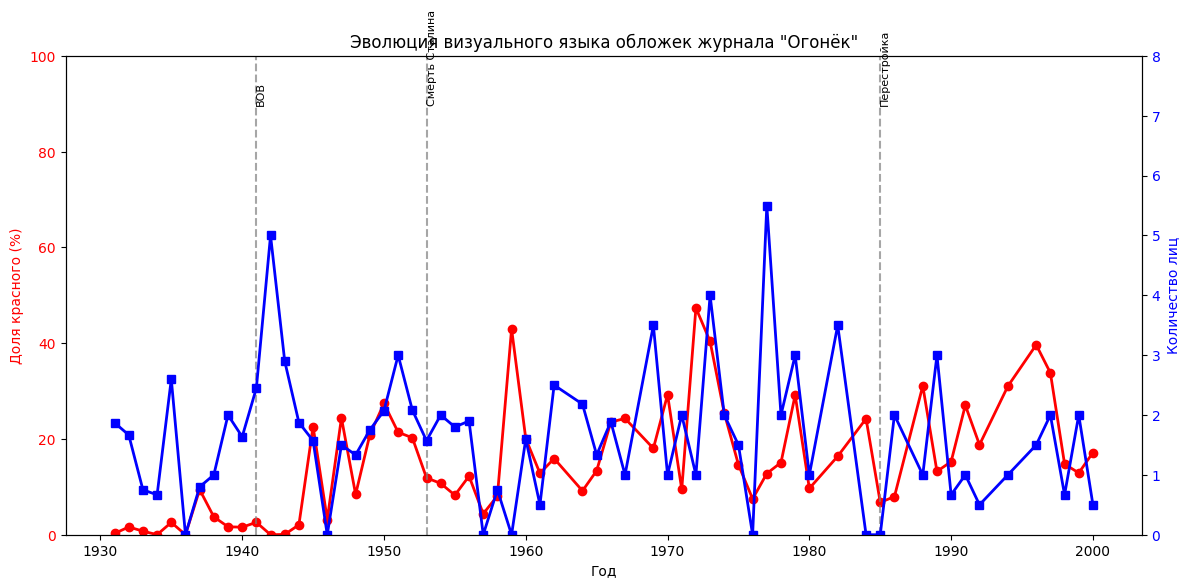

In [38]:
df = pd.read_csv("full_analysis.csv")

# График 1: динамика красного и лиц
fig, ax1 = plt.subplots(figsize=(12, 6))

yearly = (
    df.groupby("year")
      .agg({
          "red_ratio": "mean",
          "face_count": "mean"
      })
      .reset_index()
)

ax1.plot(
    yearly["year"],
    yearly["red_ratio"],
    "r-o",
    linewidth=2,
    label="Доля красного (%)"
)

ax1.set_xlabel("Год")
ax1.set_ylabel("Доля красного (%)", color="r")
ax1.tick_params(axis="y", labelcolor="r")
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()

ax2.plot(
    yearly["year"],
    yearly["face_count"],
    "b-s",
    linewidth=2,
    label="Среднее число лиц"
)

ax2.set_ylabel("Количество лиц", color="b")
ax2.tick_params(axis="y", labelcolor="b")
ax2.set_ylim(0, 8)

events = {
    1941: "ВОВ",
    1953: "Смерть Сталина",
    1985: "Перестройка"
}

for year, label in events.items():

    ax1.axvline(
        x=year,
        color="gray",
        linestyle="--",
        alpha=0.7
    )

    ax1.text(
        year,
        ax1.get_ylim()[1] * 0.9,
        label,
        rotation=90,
        fontsize=8
    )

plt.title(
    'Эволюция визуального языка обложек журнала "Огонёк"'
)

fig.tight_layout()

plt.savefig(
    "red_faces_trend.png",
    dpi=150
)

plt.show()

# Интерпритация
#
В период до 1945 года видим практически нулевое содержание красного цвета на обложках в связи с черно-белой печатью. Необычные выбросы (например, в 1936 году) объясняются некачественным сканом и ненормированным балансом белого.
#
Количество лиц на обложках в это же время особенно велик в 1940-е и 1970-е. 

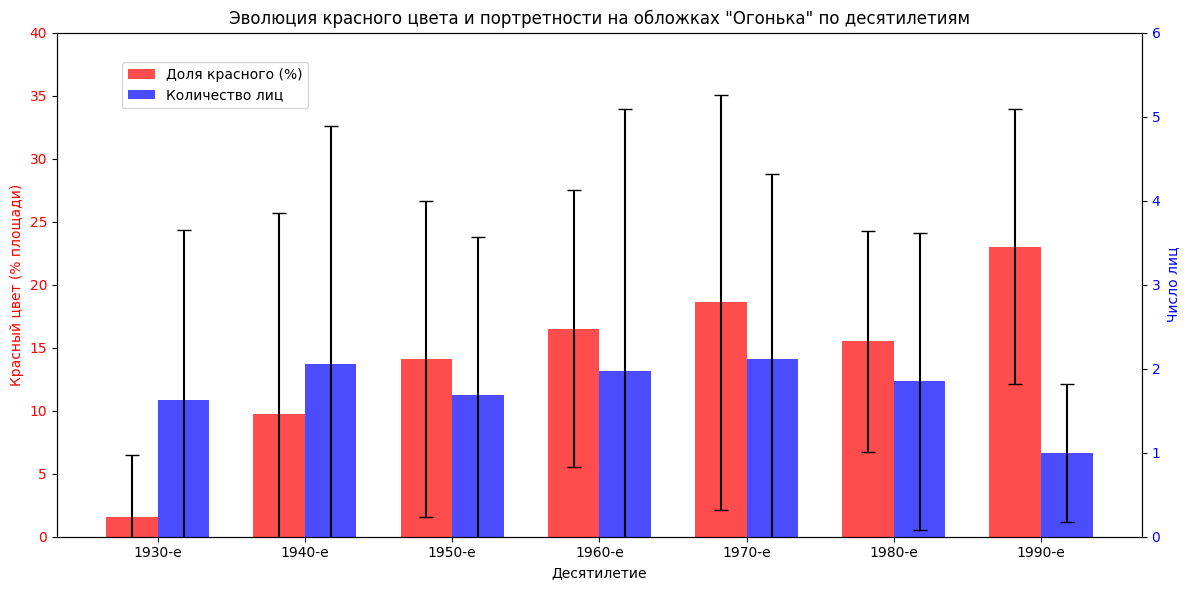

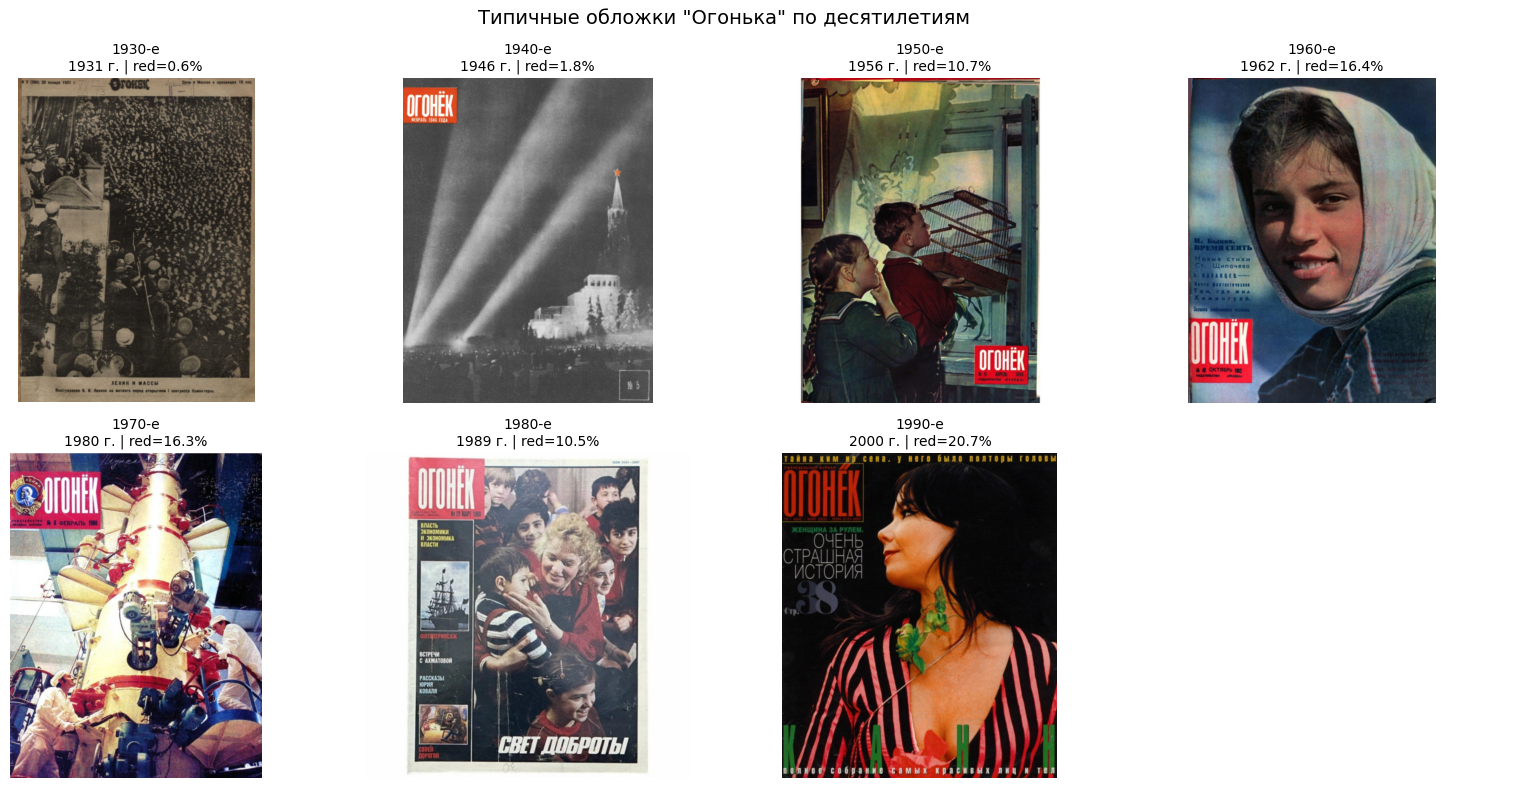

In [34]:
df = pd.read_csv("full_analysis.csv")

def assign_period(year):
    if year < 1941:
        return '1930-е'
    elif year < 1951:
        return '1940-е'
    elif year < 1961:
        return '1950-е'
    elif year < 1971:
        return '1960-е'
    elif year < 1981:
        return '1970-е'
    elif year < 1991:
        return '1980-е'
    else:
        return '1990-е'

df['period'] = df['year'].apply(assign_period)

period_stats = df.groupby('period').agg({
    'red_ratio': ['mean', 'std', 'count'],
    'face_count': ['mean', 'std']
}).round(2)

period_stats.columns = [
    'red_mean',
    'red_std',
    'n',
    'face_mean',
    'face_std'
]

period_stats = period_stats.reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(period_stats))
width = 0.35

ax1.bar(
    [i - width / 2 for i in x],
    period_stats['red_mean'],
    width,
    yerr=period_stats['red_std'],
    capsize=5,
    color='red',
    alpha=0.7,
    label='Доля красного (%)'
)

ax1.set_ylabel(
    'Красный цвет (% площади)',
    color='red'
)

ax1.tick_params(
    axis='y',
    labelcolor='red'
)

ax1.set_ylim(0, 40)

ax2 = ax1.twinx()

ax2.bar(
    [i + width / 2 for i in x],
    period_stats['face_mean'],
    width,
    yerr=period_stats['face_std'],
    capsize=5,
    color='blue',
    alpha=0.7,
    label='Количество лиц'
)

ax2.set_ylabel(
    'Число лиц',
    color='blue'
)

ax2.tick_params(
    axis='y',
    labelcolor='blue'
)

ax2.set_ylim(0, 6)

ax1.set_xticks(list(x))
ax1.set_xticklabels(period_stats['period'])

ax1.set_xlabel('Десятилетие')

plt.title(
    'Эволюция красного цвета и портретности на обложках "Огонька" по десятилетиям'
)

fig.legend(
    loc='upper left',
    bbox_to_anchor=(0.1, 0.9)
)

plt.tight_layout()

plt.savefig(
    "red_faces_periods.png",
    dpi=150
)

plt.show()


def get_representative_image(period_df, input_folder):

    # Обложка с медианным значением доли красного цвета
    median_red = period_df['red_ratio'].median()

    representative = period_df.iloc[
        (period_df['red_ratio'] - median_red)
        .abs()
        .argsort()[:1]
    ]

    filename = representative.iloc[0]['filename']
    year = representative.iloc[0]['year']
    red = representative.iloc[0]['red_ratio']

    img_path = os.path.join(
        input_folder,
        filename
    )

    return img_path, year, red


input_folder = "ogonek_processed"

periods_order = [
    '1930-е',
    '1940-е',
    '1950-е',
    '1960-е',
    '1970-е',
    '1980-е',
    '1990-е'
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

axes = axes.flatten()

for i, period in enumerate(periods_order):

    period_df = df[df['period'] == period]

    if len(period_df) == 0:
        continue

    img_path, year, red = get_representative_image(
        period_df,
        input_folder
    )

    img = Image.open(img_path)

    axes[i].imshow(img)

    axes[i].set_title(
        f'{period}\n{year} г. | red={red:.1f}%',
        fontsize=10
    )

    axes[i].axis('off')

for j in range(len(periods_order), len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Типичные обложки "Огонька" по десятилетиям',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "collage_periods.png",
    dpi=150
)

plt.show()

# Интерпритация
#
Наблюдается устойчивый рост доли красного цвета с 1930-х до 1970-х годов (примерно с 1–2 % до 18–19 % площади обложки). В 1980-е годы доля красного цвета несколько снижается, однако в 1990-е достигает максимальных значений. Вероятно, это связано уже не с идеологической функцией цвета, а с изменением издательского дизайна и использованием более ярких коммерческих визуальных решений.
#
Количество лиц на обложках остаётся относительно стабильным в период с 1940-х по 1980-е годы и колеблется около двух человек на обложку. Однако в 1990-е годы наблюдается заметное снижение показателя. Это может свидетельствовать о переходе от портретных и репортажных композиций к иным типам визуальной подачи материала.
#
Важно отметить, что вертикальные линии показывают значительный разброс значений внутри десятилетий, поэтому изменения нельзя считать абсолютно однородными: различные номера журнала могли существенно отличаться друг от друга по визуальному оформлению.

# Ограничения

1. Haar Cascades могут пропускать лица
2. Красный цвет не всегда является идеологическим маркером, кроме того, заголовок журнала уже включается в себя красный цвет
3. Часть обложек имеет разное качество сканирования, так же некоторые имеют более теплый оттенок, повышая % содержания красного
4. Метаданные по годам извлекаются автоматически и могут содержать ошибки